In [39]:
#Importing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [40]:
x = 6* np.random.rand(100,1) -3

In [41]:
y = 0.5*(x**2) + 1.5*x + 2 + np.random.randn(100,1)

Text(0, 0.5, 'Y Dataset')

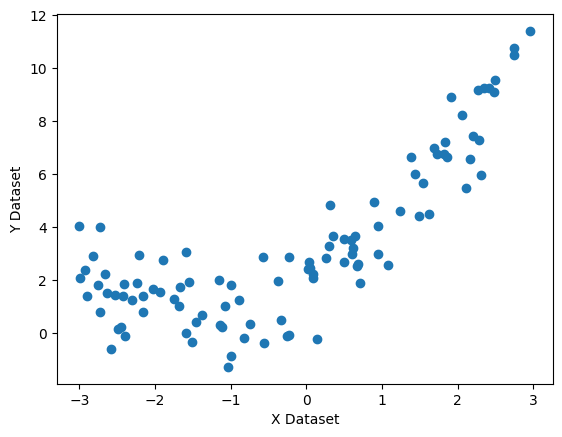

In [42]:
plt.scatter(x,y)
plt.xlabel('X Dataset')
plt.ylabel("Y Dataset")

USING LINEAR REGRESSION ON A NON-LINEAR DATASET TO PROVE THAT IT IS VERY BAD!!!

In [43]:
from sklearn.model_selection import train_test_split

In [45]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [50]:
x_train = scaler.fit_transform(x_train)

In [51]:
x_test = scaler.transform(x_test)

In [52]:
from sklearn.linear_model import LinearRegression

In [53]:
regression = LinearRegression()

In [54]:
regression.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Text(0, 0.5, 'Y Datasets')

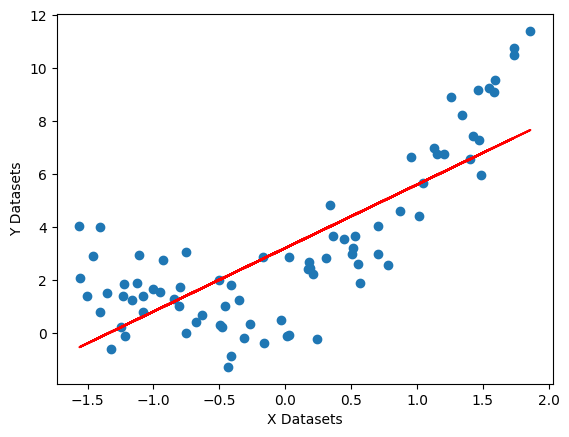

In [60]:
plt.scatter(x_train, y_train)
plt.plot(x_train, regression.predict(x_train), color = 'red', label = 'Linear Regresssion Best Fit Line')
plt.xlabel('X Datasets')
plt.ylabel('Y Datasets')

In [62]:
from sklearn.metrics import r2_score

In [63]:
linear_score = r2_score(y_test, regression.predict(x_test))

In [68]:
print(int(linear_score*100),"%")

60 %


NOW USING POLYNOMIAL REGRESSION ON A NON-LINEAR DATASET

In [70]:
#Importing PolynomialFeatures
from sklearn.preprocessing import PolynomialFeatures

In [71]:
poly = PolynomialFeatures(degree=2,include_bias=True)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

In [72]:
#Now using Linear Regression
regression.fit(x_train_poly, y_train)
y_pred = regression.predict(x_test_poly)

poly_score = r2_score(y_test, y_pred)
print(poly_score)

0.8561617209770775


In [73]:
print(regression.coef_)

[[0.         2.09225779 1.7681543 ]]


In [74]:
regression.intercept_

array([1.45106294])

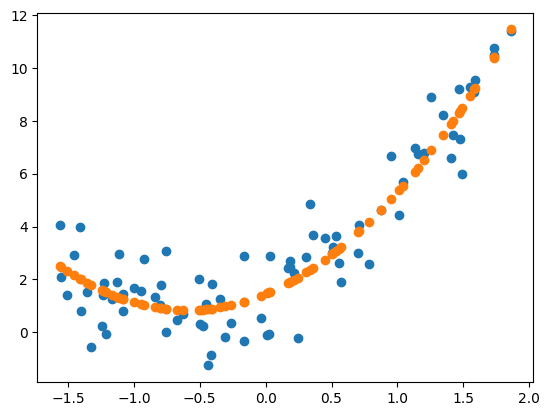

In [77]:
plt.scatter(x_train,y_train)
plt.scatter(x_train, regression.predict(x_train_poly))

In [81]:
# USING degree = 3
new_poly = PolynomialFeatures(degree =3, include_bias=True)

In [82]:
X_train_poly = poly.fit_transform(x_train)
X_test_poly = poly.transform(x_test)

In [83]:
print(r2_score(y_test, regression.predict(X_test_poly)))

0.8561617209770775
